In [1]:
pip install torch transformers scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


🚀 [Start] XLM-RoBERTa (Standard Protocol)...


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]


🥊 Step 1: 5-Fold CV on Train Set...
   Running Fold 1/5...

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

   Running Fold 5/5...

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✅ 5-Fold CV 平均 F1: 0.2515

🚀 Step 2: Final Training (Full Train Set)...


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Epoch 1: Acc 0.6499
   Epoch 2: Acc 0.6684
   Epoch 3: Acc 0.6790

🏆 【 Facebook-RoBERTa 模型訓練結果：五大指標成績表 】
Metric          | Score     
------------------------------
Accuracy        | 0.6810
Precision       | 0.5601
Recall          | 0.4029
F1-Score        | 0.4687
AUROC           | 0.7051
------------------------------
10-Fold F1      | 0.2515


📌 模型詳細報告：FacebookAI/xlm-roberta-base
--------------------------------------------------------------------------------
【 三大指標詳細成績表 】
              precision    recall  f1-score   support

           0     0.7216    0.8302    0.7721      3063
           1     0.5601    0.4029    0.4687      1643

    accuracy                         0.6810      4706
   macro avg     0.6408    0.6166    0.6204      4706
weighted avg     0.6652    0.6810    0.6662      4706

--------------------------------------------------------------------------------
【 混淆矩陣圖 】


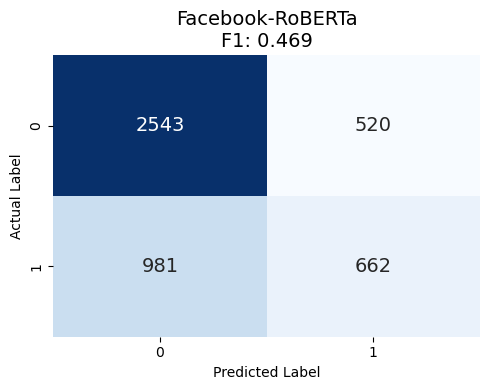

In [2]:
import pandas as pd
import numpy as np
import torch
import time
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
# 🔥 使用 Auto 系列
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW 
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_CSV = 'News_Data_cleaned.csv'
MODEL_NAME = 'FacebookAI/xlm-roberta-base' # XLM-R
MAX_LEN = 256         
BATCH_SIZE = 32       
EPOCHS = 3            
LEARNING_RATE = 2e-5  
CV_FOLDS = 5         
SEED = 42

if torch.backends.mps.is_available(): DEVICE = torch.device("mps")
elif torch.cuda.is_available(): DEVICE = torch.device("cuda")
else: DEVICE = torch.device("cpu")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed_value)

set_seed(SEED)

# ==========================================
# 🔧 資料集與函數
# ==========================================
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        enc = self.tokenizer.encode_plus(str(self.texts[item]), add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

def train_epoch(model, loader, opt, device, sched):
    model.train()
    loss_vals, corrects = [], 0
    for d in loader:
        opt.zero_grad()
        out = model(d['input_ids'].to(device), d['attention_mask'].to(device), labels=d['labels'].to(device))
        loss = out.loss; loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        
        _, preds = torch.max(out.logits, dim=1)
        corrects += torch.sum(preds == d['labels'].to(device))
        loss_vals.append(loss.item())
    return corrects.float()/len(loader.dataset), np.mean(loss_vals)

def eval_model(model, loader, device):
    model.eval()
    preds_all, lbls_all, probs_all = [], [], []
    with torch.no_grad():
        for d in loader:
            out = model(d['input_ids'].to(device), d['attention_mask'].to(device), labels=d['labels'].to(device))
            probs_all.extend(torch.softmax(out.logits, dim=1)[:, 1].cpu().numpy())
            _, preds = torch.max(out.logits, dim=1)
            preds_all.extend(preds.cpu().numpy())
            lbls_all.extend(d['labels'].numpy())
    return accuracy_score(lbls_all, preds_all), 0, preds_all, lbls_all, probs_all

# ==========================================
# 🚀 主流程
# ==========================================
if __name__ == '__main__':
    print(f"🚀 [Start] XLM-RoBERTa (Standard Protocol)...")
    if not os.path.exists(INPUT_CSV): exit()
    df = pd.read_csv(INPUT_CSV)
    if 'title_clean' not in df.columns: df['title_clean'] = df['title'].astype(str)
    df = df.dropna(subset=['title_clean', 'label'])
    df['label'] = df['label'].astype(int)
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    X = df['title_clean'].values
    y = df['label'].values
    
    # 1. 切分 80/20
    X_tr_full, X_te, y_tr_full, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
    
    # 2. 5-Fold CV
    print(f"\n🥊 Step 1: 5-Fold CV on Train Set...")
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    fold_f1s = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_full, y_tr_full)):
        print(f"   Running Fold {fold+1}/{CV_FOLDS}...", end="\r")
        tr_ds = NewsDataset(X_tr_full[tr_idx], y_tr_full[tr_idx], tokenizer, MAX_LEN)
        val_ds = NewsDataset(X_tr_full[val_idx], y_tr_full[val_idx], tokenizer, MAX_LEN)
        tr_ld = DataLoader(tr_ds, BATCH_SIZE, shuffle=True)
        val_ld = DataLoader(val_ds, BATCH_SIZE)
        
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
        opt = AdamW(model.parameters(), lr=LEARNING_RATE)
        sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)
        
        train_epoch(model, tr_ld, opt, DEVICE, sch)
        _, _, preds, labels, _ = eval_model(model, val_ld, DEVICE)
        fold_f1s.append(f1_score(labels, preds, average='binary'))
        del model
        
    print(f"   ✅ 5-Fold CV 平均 F1: {np.mean(fold_f1s):.4f}")

    # 3. Final Training
    print(f"\n🚀 Step 2: Final Training (Full Train Set)...")
    full_tr_ds = NewsDataset(X_tr_full, y_tr_full, tokenizer, MAX_LEN)
    te_ds = NewsDataset(X_te, y_te, tokenizer, MAX_LEN)
    tr_ld = DataLoader(full_tr_ds, BATCH_SIZE, shuffle=True)
    te_ld = DataLoader(te_ds, BATCH_SIZE)
    
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
    opt = AdamW(model.parameters(), lr=LEARNING_RATE)
    sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)
    
    for epoch in range(EPOCHS):
        acc, _ = train_epoch(model, tr_ld, opt, DEVICE, sch)
        print(f"   Epoch {epoch+1}: Acc {acc:.4f}")

    # 4. Final Evaluation
    test_acc, _, test_preds, test_labels, test_probs = eval_model(model, te_ld, DEVICE)
    test_f1 = f1_score(test_labels, test_preds, average='binary')
    test_prec = precision_score(test_labels, test_preds, average='binary')
    test_rec = recall_score(test_labels, test_preds, average='binary')
    test_auroc = roc_auc_score(test_labels, test_probs)

    # 輸出結果
    print("\n" + "="*60)
    print(f"🏆 【 Facebook-RoBERTa 模型訓練結果：五大指標成績表 】")
    print("="*60)
    print(f"{'Metric':<15} | {'Score':<10}")
    print("-" * 30)
    print(f"{'Accuracy':<15} | {test_acc:.4f}")
    print(f"{'Precision':<15} | {test_prec:.4f}")
    print(f"{'Recall':<15} | {test_rec:.4f}")
    print(f"{'F1-Score':<15} | {test_f1:.4f}")
    print(f"{'AUROC':<15} | {test_auroc:.4f}")
    print("-" * 30)
    print(f"{'10-Fold F1':<15} | {np.mean(fold_f1s):.4f}")
    print("\n")
    print("="*80)
    print(f"📌 模型詳細報告：{MODEL_NAME}")
    print("-" * 80)
    print("【 三大指標詳細成績表 】")
    print(classification_report(test_labels, test_preds, digits=4))
    print("-" * 80)
    print(f"【 混淆矩陣圖 】")
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
    plt.title(f'Facebook-RoBERTa\nF1: {test_f1:.3f}', fontsize=14)
    plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()